In [1]:
!pip install qiskit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.3 MB/s eta 0:00:00


In [2]:
!pip install qiskit.visualization

ERROR: Could not find a version that satisfies the requirement qiskit.visualization (from versions: none)
ERROR: No matching distribution found for qiskit.visualization


In [3]:
from qiskit import visualization

In [4]:
from qiskit import __version__
print(__version__)

2.5.2


In [5]:
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00


## Testing Vectors and matrices using Python

In [13]:
import numpy as np
#kets ket0 = |0> and ket1 = |1>
ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

# This is to calculate the average of propability of each ket which
print("ket average:", ket0 / 2 + ket1 /2)

M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])

M = M1 / 2 + M2 /2
print("M average:", M)
print("further maths using Matrix multiplications:")
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)

ket average: [[0.5]
 [0.5]]
M average: [[1.  0.5]
 [0.  0.5]]
further maths using Matrix multiplications:
[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [14]:
from qiskit.visualization import array_to_latex

display(array_to_latex(M1 @ ket1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [15]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

U  = Statevector([1 / sqrt(2), 1 / sqrt(2)])
V = Statevector([(1 + 2.0j) / 3, -2 / 3])
W = Statevector([1 / 3, 2 / 3])

In [16]:
display(U.draw("text"))
display(U.draw("latex"))
print(U.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


In [17]:
display(U.is_valid())
display(W.is_valid())

True

False

In [18]:
display(V.draw("Latex"))

<IPython.core.display.Latex object>

In [19]:
outcome, state = V.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

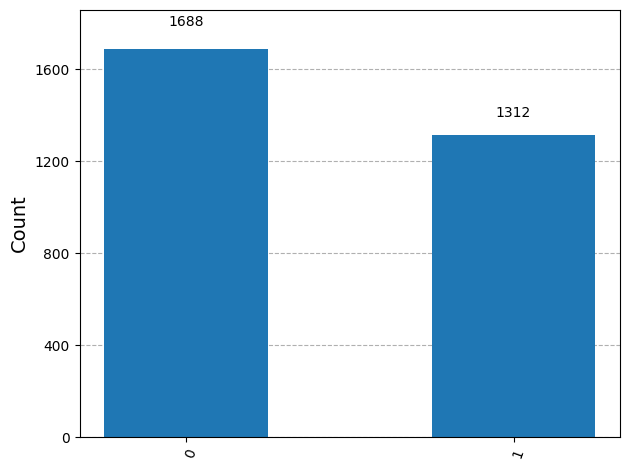

In [24]:
from qiskit.visualization import plot_histogram

statistics = V.sample_counts(3000)
plot_histogram(statistics)

In [26]:
from qiskit.quantum_info import Operator
Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [28]:
V = Statevector([1, 0])

V = V.evolve(H)
V = V.evolve(T)
V = V.evolve(H)
V = V.evolve(S)
V = V.evolve(Y)

display(V.draw("latex"))

<IPython.core.display.Latex object>

## Quatum Circuits using a sequence of unitary operations

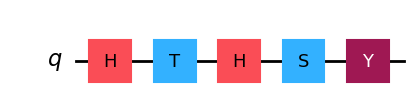

In [29]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

In [30]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

In [31]:
ket0 = Statevector([1, 0])
V = ket0.evolve(circuit)
display(V.draw("latex"))

<IPython.core.display.Latex object>

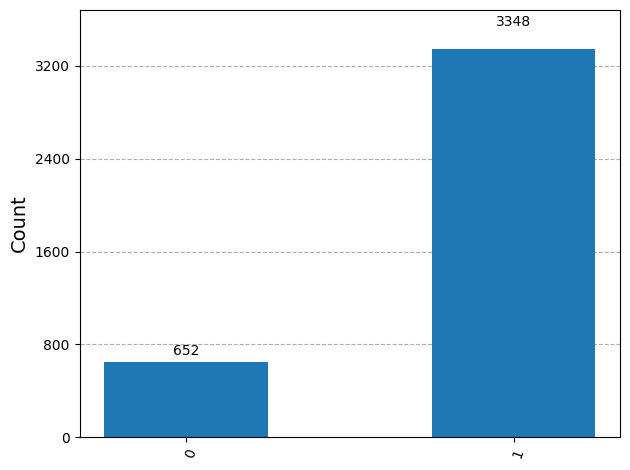

In [32]:
statistics = V.sample_counts(4000)
display(plot_histogram(statistics))